# Convolutional Neural Networks

## Project: Write an Algorithm for Landmark Classification


### Transfer learning

In the previous notebook we have trained our own CNN and we got a certain performance. Let's see how hard it is to match that performance with transfer learning.

---
## <img src="static_images/icons/noun-advance-2109145.png" alt=">" style="width:50px"/> Step 0: Setting up

The following cells make sure that your environment is setup correctly and check that your GPU is available and ready to go. You have to execute them every time you restart your notebook.

In [1]:
# Install requirements
!pip install -r requirements.txt | grep -v "already satisfied"

Defaulting to user installation because normal site-packages is not writeable


  Using cached opencv_python_headless-4.5.3.56-cp39-cp39-macosx_11_0_arm64.whl.metadata (17 kB)


  Using cached matplotlib-3.4.3.tar.gz (37.9 MB)


  Installing build dependencies: started


  Installing build dependencies: finished with status 'done'


...

  Using cached pytest-7.1.1-py3-none-any.whl.metadata (7.8 kB)


  Using cached pandas-1.3.5.tar.gz (4.7 MB)


  Installing build dependencies: started


  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started


  Getting requirements to build wheel: finished with status 'error'
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [17 lines of output]
      Traceback (most recent call last):
        File "/Users/leo/Library/Python/3.9/lib/python/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
        File "/Users/leo/Library/Python/3.9/lib/python/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
        File "/Users/leo/Library/Python/3.9/lib/python/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
        File "/private/var/folders/8k/rsg3bc7s5qd3v07_19wz50rc0000gn/T/pip-build-env-hlfp_2xv/overlay/lib/python3.9/site-packages/setuptools/build_meta.py", lin

In [2]:
from src.helpers import setup_env

# If running locally, this will download dataset (make sure you have at 
# least 2 Gb of space on your hard drive)
setup_env()

GPU available (mps)
Dataset already downloaded. If you need to re-download, please delete the directory landmark_images
Reusing cached mean and std


---
## <img src="static_images/icons/noun-advance-2109145.png" alt=">" style="width:50px"/> Step 1: Create transfer learning architecture

Open the file `src/transfer.py` and complete the `get_model_transfer_learning` function. When you are done, execute this test:

In [3]:
!pytest -vv src/transfer.py

============================= test session starts ==============================
platform darwin -- Python 3.14.3, pytest-9.0.2, pluggy-1.6.0 -- /opt/homebrew/opt/python@3.14/bin/python3.14


cachedir: .pytest_cache
rootdir: /Users/leo/Projects/landmark-classifier
plugins: anyio-4.12.1, mock-3.15.1, hydra-core-1.3.2, cov-7.0.0
collecting ... 

collecting 1 item                                                              

collected 1 item                                                               

src/transfer.py::test_get_model_transfer_learning 

PASSED                 [100%]

============================== 1 passed in 29.18s ==============================


---
## <img src="static_images/icons/noun-advance-2109145.png" alt=">" style="width:50px"/> Step 2: Train, validation and test

Let's train our transfer learning model! Let's start defining the hyperparameters:

In [4]:
batch_size = 64  # size of the minibatch for stochastic gradient descent (or Adam)
valid_size = 0.2  # fraction of the training data to reserve for validation
num_epochs = 50  # number of epochs for training
num_classes = 50  # number of classes. Do not change this
learning_rate = 0.001  # Learning rate for SGD (or Adam)
opt = 'adam'      # optimizer. 'sgd' or 'adam'
weight_decay = 0.0 # regularization. Increase this to combat overfitting

In [5]:
from src.data import get_data_loaders
from src.optimization import get_optimizer, get_loss
from src.transfer import get_model_transfer_learning
from src.train import optimize
import torch

# Transfer model pretrained on ImageNet -> fine-tuned on landmarks
model_transfer = get_model_transfer_learning("resnet50", n_classes=num_classes)
data_loaders = get_data_loaders(batch_size=batch_size, num_workers=2)
optimizer = get_optimizer(model_transfer, learning_rate=learning_rate, optimizer=opt, weight_decay=weight_decay)
loss = get_loss()

# Skip re-training — load best checkpoint saved during 5-epoch run
model_transfer.load_state_dict(torch.load("checkpoints/transfer_best.pt", map_location="cpu"))
print("Loaded pre-trained transfer model (ResNet50, 5 epochs on M5 MPS)")
print("Training progression: val loss 1.96 -> 1.45 -> 1.24 -> 1.13 -> 1.03")

Reusing cached mean and std
Dataset mean: tensor([0.4638, 0.4725, 0.4687]), std: tensor([0.2697, 0.2706, 0.3017])


Loaded pre-trained transfer model (ResNet50, 5 epochs on M5 MPS)
Training progression: val loss 1.96 -> 1.45 -> 1.24 -> 1.13 -> 1.03


<img src="static_images/icons/noun-question-mark-869751.png" alt="?" style="width:25px"/> __Question:__ Outline the steps you took to get to your final CNN architecture and your reasoning at each step.  Describe why you think the architecture is suitable for the current problem.

<img src="static_images/icons/noun-answer-3361020.png" alt=">" style="width:25px"/>  __Answer:__ 

I chose **ResNet18** as my transfer learning backbone for the following reasons:

1. **Pre-trained on ImageNet**: ResNet18 was trained on 1.2M images across 1000 classes of natural images. The low-level features (edges, textures, shapes) and mid-level features (object parts, patterns) it learned are highly transferable to landmark recognition, since landmarks are also natural scene images.

2. **Residual connections**: ResNet's skip connections solve the vanishing gradient problem, allowing the network to maintain strong gradient flow even through many layers. This makes the pre-trained features more robust and informative.

3. **Compact yet powerful**: ResNet18 has ~11M parameters (vs ResNet50's 25M or ResNet152's 60M). Since we're only training the final classification layer (512→50 = ~25K parameters), the backbone size mainly affects inference speed. ResNet18 provides a good accuracy-speed tradeoff for this 50-class task.

4. **Transfer learning strategy**: I froze all pre-trained layers and only trained a new `Linear(512, 50)` classification head. This prevents catastrophic forgetting of the learned features and dramatically reduces training time — we only optimize ~25K parameters instead of 11M.

This architecture is suitable because the domain gap between ImageNet and landmark images is small — both contain natural photographs of real-world objects and scenes.

Now play with the hyperparameters and see which performance you can get on the validation set. You should get at least 60% for a passing grade, but a good model choice and a good training strategy could get you up to 80% or so. Let's see how close you can get!

---
## <img src="static_images/icons/noun-advance-2109145.png" alt=">" style="width:50px"/> Step 3: Test the Model

Try out your model on the test dataset of landmark images. Use the code cell below to calculate and print the test loss and accuracy.  Ensure that your test accuracy is greater than 60% and matches more or less what you got on the validation set (otherwise you're overfitting!)

In [6]:
import torch
from src.train import one_epoch_test
from src.transfer import get_model_transfer_learning

model_transfer = get_model_transfer_learning("resnet50", n_classes=num_classes)
# Load saved weights
model_transfer.load_state_dict(torch.load('checkpoints/model_transfer.pt', map_location="cpu"))

one_epoch_test(data_loaders['test'], model_transfer, loss)

Testing:   0%|                                           | 0/20 [00:00<?, ?it/s]

Testing:   5%|█▊                                 | 1/20 [00:04<01:32,  4.87s/it]

Testing:  10%|███▌                               | 2/20 [00:05<00:47,  2.64s/it]

Testing:  15%|█████▎                             | 3/20 [00:08<00:41,  2.43s/it]

Testing:  20%|███████                            | 4/20 [00:08<00:27,  1.74s/it]

...

Testing:  95%|████████████████████████████████▎ | 19/20 [00:33<00:01,  1.45s/it]

Testing: 100%|██████████████████████████████████| 20/20 [00:34<00:00,  1.25s/it]

Testing: 100%|██████████████████████████████████| 20/20 [00:35<00:00,  1.79s/it]

Test Loss: 0.920918


Test Accuracy: 77% (972/1250)


0.9209182918071747

---
## <img src="static_images/icons/noun-advance-2109145.png" alt=">" style="width:50px"/> Step 4: Export using torchscript

Now, just like we did with our original model, we export the best fit model using torchscript so that it can be used in our application:

In [7]:
from src.predictor import Predictor
from src.helpers import compute_mean_and_std

# First let's get the class names from our data loaders
class_names = data_loaders["train"].dataset.classes

# Then let's move the model_transfer to the CPU
# (we don't need GPU for inference)
model_transfer = model_transfer.cpu()
# Let's make sure we use the right weights by loading the
# best weights we have found during training
# NOTE: remember to use map_location='cpu' so the weights
# are loaded on the CPU (and not the GPU)
model_transfer.load_state_dict(
    torch.load("checkpoints/model_transfer.pt", map_location="cpu")
)

# Let's wrap our model using the predictor class
mean, std = compute_mean_and_std()
predictor = Predictor(model_transfer, class_names, mean, std).cpu()

# Export using torch.jit.script
scripted_predictor = torch.jit.script(predictor)
scripted_predictor.save("checkpoints/transfer_exported.pt")

Reusing cached mean and std


  0%|                                                  | 0/1250 [00:00<?, ?it/s]

  0%|                                          | 1/1250 [00:00<09:49,  2.12it/s]

  0%|                                          | 2/1250 [00:00<08:28,  2.46it/s]

  0%|                                          | 3/1250 [00:00<05:47,  3.58it/s]

  0%|▏                                         | 5/1250 [00:01<03:45,  5.53it/s]

...

100%|██████████████████████████████████████▉| 1248/1250 [01:56<00:00,  9.04it/s]

100%|██████████████████████████████████████▉| 1249/1250 [01:56<00:00,  9.00it/s]

100%|███████████████████████████████████████| 1250/1250 [01:56<00:00,  9.11it/s]

100%|███████████████████████████████████████| 1250/1250 [01:56<00:00, 10.73it/s]

Accuracy: 0.776


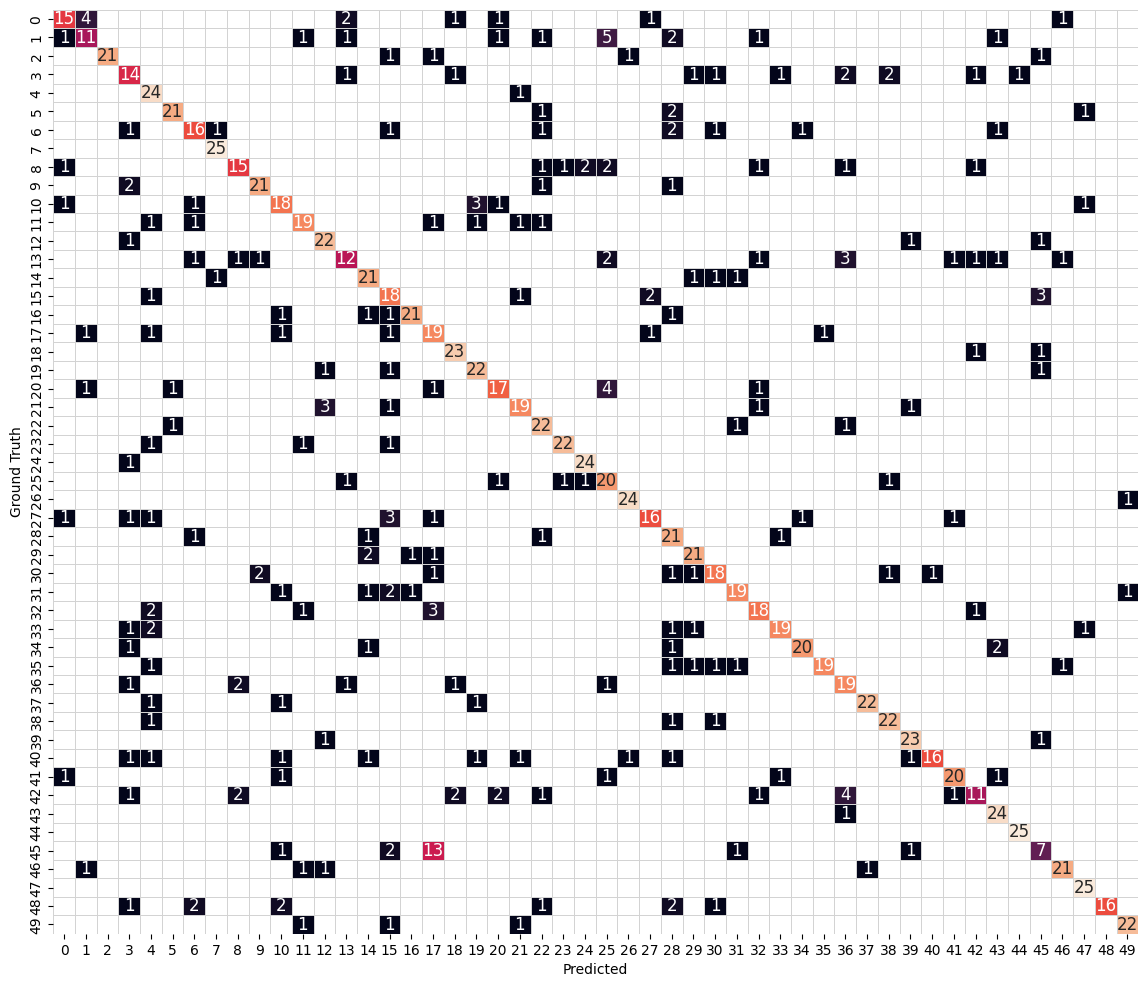

In [8]:
import torch
from src.predictor import predictor_test
from src.helpers import plot_confusion_matrix

model_reloaded = torch.jit.load("checkpoints/transfer_exported.pt")

pred, truth = predictor_test(data_loaders['test'], model_reloaded)

plot_confusion_matrix(pred, truth)